Hi, this is a test text with an equation: $a=b$

In [4]:
%matplotlib widget

In [1]:
import importlib
import field
importlib.reload(field)

from field import Field


In [2]:
# if you changed the code in field.py, run the above cell first
import os
from datetime import date

#datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\2024-1-02'

qadate = date(2024, 1, 2)
formatted_date = qadate.strftime("%Y-%m-%d")
datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date

# the specific format of the date is currently created in the __main__ of RetrieveFieldData.py
# TODO: change that


if not os.path.isdir(datafolder):
    formatted_date = f"{qadate.year}-{qadate.month}-{qadate.strftime('%d')}"
    datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date



# example of a Varian field: (field B2 for MRN 3102335 )
# ---------------------------
# filename = datafolder+'\\'+'FieldID_2406983.json' # make sure that this available locally on the computer (and not just in the cloud)

# in order to find that out, run the file RetrieveFieldData.py with the breakpoint() set 
# Q:\VMAT QA Project\Engineered Features>python RetrieveFieldData.py 2024 01 02 and then (Pdb) selection_augmented.query("FieldID == 2406983")


# example of an Elekta field (C2 for MRN 7211873):
# --------------------------
filename = datafolder+'\\'+'FieldID_2406771.json'


field = Field(filename)
# %store field



In [ ]:

import numpy as np

#print(field.cp[0]['leafSetA'])
#print(field.cp[0]['leafSetB'])

#leafposA = field.cp[0]['leafSetA']

#print(field.mq_control_points[0]['leafSetA'][field.active_leaf_start:field.active_leaf_end])
#print(field.matrixA)

# for viewing in data wrangler:
Aside = field.matrixA
BSide = field.matrixB

leafgaps = Aside+BSide



leaf_widths = np.array(field.leaf_width[leafgaps.index.min()-1: leafgaps.index.max()-1+1]) 
# just leafs matching the dataframe leafgaps, leafgaps.index indicates the leaf number starting at 1, field.leaf_width starts at index 0, the +1 makes the second index inclusive! 


areas = leafgaps.mul(leaf_widths[:, np.newaxis])

#areas[:] = 1.0 # Just to see if the summation below makes sense! 

# This trick thanks to chatGPT
ranges = {col: (field.exposed_leaf_start[areas.columns.get_loc(col)], field.exposed_leaf_end[areas.columns.get_loc(col)]) for col in areas.columns}

sums = {col: areas[col].loc[start:end].sum() for col, (start, end) in ranges.items()}

print(areas.sum()) # This was Goerge's old code 




181    149.300
183    148.305
185    139.540
187    127.245
189    117.330
        ...   
171    203.470
173    191.025
175    179.520
177    166.375
179    160.105
Length: 180, dtype: float64


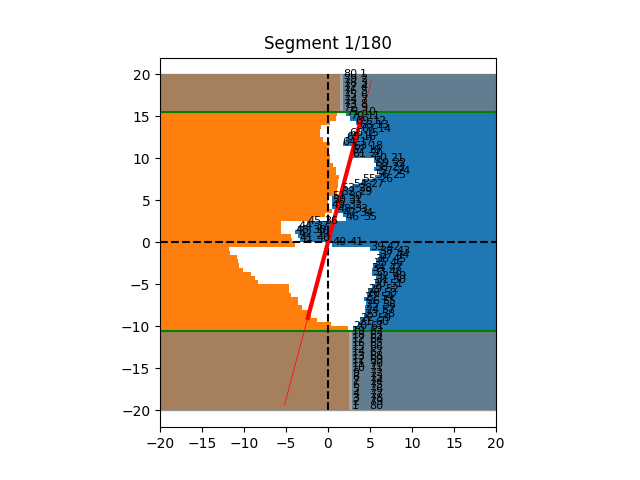

Collimator X1 =  15.5
Collimator X2 =  10.5
Collimator Y1 =  None
Collimator Y2 =  None
10
61
10    2.17
11    2.64
12    3.28
13    3.69
14    3.96
15    2.52
16    2.15
17    1.74
18    3.00
19    2.72
20    2.86
21    5.44
22    5.67
23    5.51
24    6.08
25    5.63
26    4.07
27    2.99
28    1.54
29    1.53
30    0.45
31    0.45
32    0.45
33    1.14
34    1.75
35    2.13
36   -2.50
37   -3.57
38   -3.91
39   -3.56
40   -3.35
41    0.52
42    5.00
43    6.09
44    6.08
45    5.67
46    5.37
47    5.20
48    5.22
49    5.67
50    5.60
51    5.25
52    4.79
53    4.59
54    4.26
55    4.50
56    4.44
57    4.38
58    4.33
59    3.85
60    3.62
61    3.01
Name: 181, dtype: float64
345
-9.316837378728433
15.292006178780762


In [7]:
### In this cell, we are testing the plotting capabilities
### -------------------------------------------------------
#from plotting_HK import plot_segment 
# # I changed Georg's original code to use the field as the first parameter, and not field_info which is not directly returned with Field()

# have to reimport this function whenever we change the function plot_segment()
import importlib
import plotting_HK
importlib.reload(plotting_HK)

from plotting_HK import plot_segment

segmentno = 0 # with 0 the first
plot_segment(field, segmentno)

print('Collimator X1 = ', field.cp[segmentno]['collimatorX1'])
print('Collimator X2 = ', field.cp[segmentno]['collimatorX2'])
print('Collimator Y1 = ', field.cp[segmentno]['collimatorY1'])
print('Collimator Y2 = ', field.cp[segmentno]['collimatorY2'])

print(field.exposed_leaf_start[segmentno])
print(field.exposed_leaf_end[segmentno])


print(field.matrixA.loc[field.exposed_leaf_start[segmentno]:field.exposed_leaf_end[segmentno], 
                        field.matrixA.columns[segmentno]])

print(field.collimatorAngle)
print(field.cp[segmentno]['spanMin'])
print(field.cp[segmentno]['spanMax'])


In [ ]:
### Some testing with the Metadatafile
import os
import pandas as pd

qadate = date(2024, 1, 2)
formatted_date = qadate.strftime("%Y-%m-%d")
datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date
# the specific format of the date is currently created in the __main__ of RetrieveFieldData.py
# TODO: change that


if not os.path.isdir(datafolder):
    formatted_date = f"{qadate.year}-{qadate.month}-{qadate.strftime('%d')}"
    datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date

mdfiles = [f for f in os.listdir(datafolder) if f.startswith('FieldsMetaData') and os.path.isfile(os.path.join(datafolder, f))]
file_name = os.path.join(datafolder, mdfiles[0])

df = pd.read_json(file_name)


# TODO: read all field data files in that folder
#  extract the span from each field
# add a column to df with the span
# write the amended df to a new metadata file

In [1]:
%reset -f